# Online Drift Detection on Real Validation Streams

**Chapter 26: MLOps and Governance**
**Docker image**: `ml4t`
**Book Reference**: Chapter 26, Section 26.3
**Prerequisites**: Drift basics from [`01_drift_monitoring`](01_drift_monitoring.ipynb) and Chapter 25 deployment verification.

**Learning Objectives**:
- Compare a lightweight two-window mean-shift detector against a DDM-style
  error-rate monitor on real chronological prediction streams.
- Layer detector alerts against a market-stress proxy so a desk can
  contextualize error spikes without claiming a degradation label.
- Translate alert timing into a signed lead/lag measure against known
  stress windows.

The `us_equities_panel` case study contains real pre-promotion prediction
streams for the final validation year before the sealed holdout. We use two
linear configurations with different regularization strengths:
- `linear/ols` on `fwd_ret_1d`
- `linear/ridge` on `fwd_ret_1d`

That makes 2015 a realistic calibration period for online drift detectors.
The notebook keeps the 2016-03-31 sealed holdout untouched and asks a simpler
operational question: how often would an online detector have warned the desk
that the error stream was changing before promotion?

In [1]:
"""Online Drift Detection on Real Validation Streams — sequential drift detectors on real pre-promotion prediction streams."""

'Online Drift Detection on Real Validation Streams — sequential drift detectors on real pre-promotion prediction streams.'

In [2]:
CASE_STUDY_ID = "us_equities_panel"
PRIMARY_LABEL = "fwd_ret_1d"
VALIDATION_START = "2015-01-01"
VALIDATION_END = "2015-12-31"
TOP_N_LIQUID = 200
CALIBRATION_DAYS = 63
# Fewest assets a decision time may carry before its cross-sectional statistics
# stop meaning anything. Ten is well below the ~200-name book this runs on in
# production and well above the point where a rank correlation degenerates.
MIN_ASSETS_PER_DATE = 10
OLS_PREDICTION_HASH = "f9e84a32a9f0"
RIDGE_PREDICTION_HASH = "c0b36ffb8f51"

In [3]:
import math
import warnings
from dataclasses import dataclass

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, format_pct_axis

warnings.filterwarnings("ignore")

CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
REGISTRY_DB = CASE_DIR / "run_log" / "registry.db"

print("Online Drift Detection on Real Validation Streams")
print("=" * 60)

Online Drift Detection on Real Validation Streams


## 1. Build a real chronological error stream

The stream is restricted to the 200 most liquid names from the prior year so
detector behavior reflects a plausible execution universe rather than the full
research panel.

In [4]:
def get_liquid_universe(top_n: int) -> pl.DataFrame:
    from data import load_us_equities

    # Rank the 2015 universe using only information available through 2014.
    prices = load_us_equities(start_date="2013-11-01", end_date="2014-12-31")
    return (
        prices.lazy()
        .sort("symbol", "timestamp")
        .with_columns((pl.col("adj_close") * pl.col("adj_volume")).alias("dollar_volume"))
        .with_columns(pl.col("dollar_volume").rolling_mean(21).over("symbol").alias("adv_21d"))
        .filter(
            (pl.col("timestamp") >= pl.date(2014, 1, 1))
            & (pl.col("timestamp") <= pl.date(2014, 12, 31))
        )
        .group_by("symbol")
        .agg(pl.col("adv_21d").mean().alias("avg_adv_21d"))
        .sort("avg_adv_21d", descending=True)
        .head(top_n)
        .select("symbol")
        .collect()
    )

### Look up prediction hashes in the registry

In [5]:
def _resolve_prediction_hash(expected_hash: str, config_prefix: str) -> str:
    """Validate one pinned validation artifact against the registry and filesystem."""
    import sqlite3

    with sqlite3.connect(REGISTRY_DB) as conn:
        approved = conn.execute(
            "SELECT 1 FROM training_runs tr "
            "JOIN prediction_sets ps ON tr.training_hash = ps.training_hash "
            "WHERE ps.prediction_hash = ? AND tr.family = 'linear' AND tr.label = ? "
            "AND tr.config_name LIKE ? AND ps.split = 'validation' LIMIT 1",
            (expected_hash, PRIMARY_LABEL, f"{config_prefix}%"),
        ).fetchone()
    if approved is None:
        raise RuntimeError(f"Registry does not approve {config_prefix}/{expected_hash}")
    prediction_dir = CASE_DIR / "run_log" / "predictions"
    if not (prediction_dir / expected_hash / "predictions.parquet").exists():
        raise RuntimeError(f"Missing materialized prediction artifact {expected_hash}")
    return expected_hash

### Load predictions from a content-addressed hash

In [6]:
def _load_predictions_from_hash(run_hash: str, model_label: str) -> pl.LazyFrame:
    """Load predictions from a run hash using the canonical registry loader."""
    from case_studies.utils.registry import read_predictions

    df = read_predictions(CASE_STUDY_ID, run_hash)
    return df.lazy().select(
        pl.col("timestamp").cast(pl.Date).alias("timestamp"),
        pl.col("symbol"),
        pl.col("y_score").alias("score"),
        pl.col("y_true").alias("actual"),
        pl.lit(model_label).alias("model"),
    )

### Assemble the validation prediction stream

Combine OLS and ridge predictions, filtered to the liquid universe.

In [7]:
def load_validation_predictions() -> pl.DataFrame:
    liquid_universe = get_liquid_universe(TOP_N_LIQUID).lazy()
    start_date = pd.Timestamp(VALIDATION_START).date()
    end_date = pd.Timestamp(VALIDATION_END).date()
    date_filter = (pl.col("timestamp") >= pl.lit(start_date)) & (
        pl.col("timestamp") <= pl.lit(end_date)
    )

    ols_hash = _resolve_prediction_hash(OLS_PREDICTION_HASH, "ols")
    ridge_hash = _resolve_prediction_hash(RIDGE_PREDICTION_HASH, "ridge")

    linear_ols = (
        _load_predictions_from_hash(ols_hash, "linear_ols")
        .filter(date_filter)
        .join(liquid_universe, on="symbol", how="inner")
    )
    linear_ridge = (
        _load_predictions_from_hash(ridge_hash, "linear_ridge")
        .filter(date_filter)
        .join(liquid_universe, on="symbol", how="inner")
    )
    stream = pl.concat([linear_ols, linear_ridge]).collect().sort(["model", "timestamp", "symbol"])
    # Every detector below reads a cross-sectional statistic per decision time.
    # With two or three names a daily rank correlation is +/-1 by construction and
    # the drift verdict is an artifact of breadth, not of the models. Session
    # coverage alone does not catch that: a stream can span every date and still
    # carry a handful of assets on each of them.
    # Both streams have to survive the filters. A model emptied by the date or
    # liquid-universe join leaves no group to inspect, so a breadth check over
    # the groups that exist would pass while the notebook compares one model
    # against nothing.
    present = set(stream["model"].unique().to_list())
    if present != {"linear_ols", "linear_ridge"}:
        raise ValueError(
            f"Expected both prediction streams, got {sorted(present)}. The date filter "
            f"or the liquid-universe join removed one entirely."
        )
    breadth = stream.group_by(["model", "timestamp"]).agg(
        pl.col("symbol").n_unique().alias("n_assets")
    )
    if breadth["n_assets"].min() < MIN_ASSETS_PER_DATE:
        worst = breadth.sort("n_assets").row(0, named=True)
        raise ValueError(
            f"{worst['model']} carries {worst['n_assets']} assets on "
            f"{worst['timestamp']:%Y-%m-%d}, below the {MIN_ASSETS_PER_DATE} a "
            f"cross-sectional statistic needs. The prediction streams and the liquid "
            f"universe they are joined to are not covering the same names."
        )
    return stream

In [8]:
validation_predictions = load_validation_predictions()
validation_predictions.group_by("model").len()

model,len
str,u32
"""linear_ols""",48511
"""linear_ridge""",48511


In [9]:
coverage = validation_predictions.group_by("model").agg(
    pl.min("timestamp").alias("start"),
    pl.max("timestamp").alias("end"),
    pl.n_unique("timestamp").alias("sessions"),
)
assert coverage.get_column("start").n_unique() == 1
assert coverage.get_column("end").n_unique() == 1
assert coverage.get_column("sessions").min() >= 240
observed_start = pd.Timestamp(coverage.get_column("start").item(0))
observed_end = pd.Timestamp(coverage.get_column("end").item(0))
assert observed_start.year == pd.Timestamp(VALIDATION_START).year
assert observed_end >= pd.Timestamp(VALIDATION_END) - pd.Timedelta(days=7)

In [10]:
from data import load_us_equities

availability_end = (pd.Timestamp(VALIDATION_END) + pd.Timedelta(days=7)).date().isoformat()
sessions = (
    load_us_equities(start_date=VALIDATION_START, end_date=availability_end)
    .select(pl.col("timestamp").cast(pl.Date))
    .unique()
    .sort("timestamp")
)
availability = (
    sessions.rename({"timestamp": "prediction_timestamp"})
    .with_columns(timestamp=pl.col("prediction_timestamp").shift(-1))
    .drop_nulls("timestamp")
)
daily_errors = (
    validation_predictions.group_by(["model", "timestamp"])
    .agg(
        ((pl.col("actual") - pl.col("score")) ** 2).mean().alias("mse"),
        ((pl.col("score") * pl.col("actual")) <= 0).mean().alias("direction_error_rate"),
        pl.corr("score", "actual").alias("ic"),
        pl.len().alias("n_assets"),
    )
    .sort(["model", "timestamp"])
    .rename({"timestamp": "prediction_timestamp"})
    .join(availability, on="prediction_timestamp", how="inner")
    .to_pandas()
)
daily_errors["timestamp"] = pd.to_datetime(daily_errors["timestamp"])
daily_errors["prediction_timestamp"] = pd.to_datetime(daily_errors["prediction_timestamp"])
assert (daily_errors["timestamp"] > daily_errors["prediction_timestamp"]).all()
daily_errors.head()

,model,prediction_timestamp,mse,direction_error_rate,ic,n_assets,timestamp
0,linear_ols,2015-01-02,0.000901,0.829897,0.104033,194,2015-01-05
1,linear_ols,2015-01-05,0.000441,0.804124,0.110186,194,2015-01-06
2,linear_ols,2015-01-06,0.000515,0.216495,0.154862,194,2015-01-07
3,linear_ols,2015-01-07,0.000474,0.108247,0.178880,194,2015-01-08
4,linear_ols,2015-01-08,0.000249,0.618557,-0.063941,194,2015-01-09


## 2. Build a market-stress proxy for context

There is no ground-truth regime label in live trading. The notebook calibrates
a robust 21-day market-volatility proxy on 2014, then applies that fixed
threshold to the 2015 monitoring stream.

In [11]:
market_history = (
    load_us_equities(start_date="2013-12-01", end_date=VALIDATION_END)
    .sort("symbol", "timestamp")
    .with_columns(returns=pl.col("adj_close").pct_change().over("symbol"))
    .drop_nulls("returns")
    .select(pl.col("timestamp").cast(pl.Date).alias("timestamp"), "symbol", "returns")
    .join(get_liquid_universe(TOP_N_LIQUID), on="symbol", how="inner")
    .group_by("timestamp")
    .agg(pl.col("returns").median().alias("market_return"), pl.len().alias("n_assets"))
    .sort("timestamp")
    .to_pandas()
)
market_history["timestamp"] = pd.to_datetime(market_history["timestamp"])
market_history["rolling_vol_21d"] = market_history["market_return"].rolling(
    21, min_periods=21
).std() * np.sqrt(252)
calibration_market = market_history[market_history["timestamp"].dt.year == 2014]
stress_threshold = calibration_market["rolling_vol_21d"].quantile(0.80)
market_history["stress_regime"] = market_history["rolling_vol_21d"] >= stress_threshold
market_history["stress_start"] = market_history["stress_regime"] & ~market_history[
    "stress_regime"
].shift(fill_value=False)
prices = market_history[market_history["timestamp"].dt.year == 2015].copy()
stress_starts = prices.loc[prices["stress_start"], "timestamp"].tolist()

print(f"Stress threshold (annualized 21d vol): {stress_threshold:.3f}")
print("Stress windows start on:", [d.date() for d in stress_starts])

Stress threshold (annualized 21d vol): 0.157
Stress windows start on: [datetime.date(2015, 1, 28), datetime.date(2015, 8, 21), datetime.date(2015, 12, 11)]


## 3. Lightweight ADWIN-style and DDM detectors

These are notebook-scale implementations tuned for daily aggregated error
streams. The purpose is to compare operational alert behavior, not to replace
a production detector library.

In [12]:
class ADWINStyle:
    """Two-window mean-shift detector with a cooldown between alerts."""

    def __init__(self, window_size: int = 21, sensitivity: float = 1.4, cooldown_days: int = 21):
        self.window_size = window_size
        self.sensitivity = sensitivity
        self.cooldown_days = cooldown_days
        self.window: list[float] = []
        self.cooldown_remaining = 0

    def update(self, value: float) -> bool:
        self.window.append(float(value))
        if self.cooldown_remaining > 0:
            self.cooldown_remaining -= 1
            return False
        if len(self.window) < self.window_size * 2:
            return False

        recent = np.asarray(self.window[-self.window_size :], dtype=float)
        prior = np.asarray(self.window[-self.window_size * 2 : -self.window_size], dtype=float)
        pooled = np.sqrt(prior.var(ddof=1) / len(prior) + recent.var(ddof=1) / len(recent) + 1e-12)
        if pooled == 0:
            return False
        stat = abs(recent.mean() - prior.mean()) / pooled
        if stat >= self.sensitivity:
            self.cooldown_remaining = self.cooldown_days
            return True
        return False

### DDM: Drift Detection Method

Monitors whether the frequency of bad prediction days exceeds a learned baseline.

In [13]:
class DDM:
    """Daily bad-day monitor calibrated for aggregated direction-error rates."""

    def __init__(self, min_samples: int = 20, warning_level: float = 1.5, drift_level: float = 2.0):
        self.min_samples = min_samples
        self.warning_level = warning_level
        self.drift_level = drift_level
        self.reset()

    def reset(self) -> None:
        self.n_samples = 0
        self.n_errors = 0
        self.p_min = float("inf")
        self.s_min = float("inf")

    def update(self, error: bool) -> str:
        self.n_samples += 1
        self.n_errors += int(error)
        if self.n_samples < self.min_samples:
            return "normal"

        p = self.n_errors / self.n_samples
        s = math.sqrt(max(p * (1 - p) / self.n_samples, 1e-12))
        if p + s < self.p_min + self.s_min:
            self.p_min, self.s_min = p, s

        if p + s >= self.p_min + self.drift_level * self.s_min:
            return "drift"
        if p + s >= self.p_min + self.warning_level * self.s_min:
            return "warning"
        return "normal"

### Detector summary record

In [14]:
@dataclass
class DetectorSummary:
    model: str
    detector: str
    alert_count: int
    first_alert: str | None
    median_lag_days: float | None

### Measure signed lead/lag of alerts vs stress regimes

Positive lag means the stress event came after the alert (detector led the
regime change); negative lag means the alert fired after the regime had
already started. Absolute distance hides this direction.

In [15]:
def nearest_stress_lag(
    alert_dates: list[pd.Timestamp], stress_dates: list[pd.Timestamp]
) -> float | None:
    if not alert_dates or not stress_dates:
        return None
    lags: list[int] = []
    for alert_date in alert_dates:
        nearest_stress = min(
            stress_dates, key=lambda stress_date: abs((alert_date - stress_date).days)
        )
        # Signed: positive => stress occurred AFTER alert (detector led);
        # negative => alert fired AFTER stress started (detector lagged).
        lags.append((nearest_stress - alert_date).days)
    return float(np.median(lags)) if lags else None

### Run both detectors on each model stream

In [16]:
def run_adwin_stream(
    model_name: str, calibration: pd.DataFrame, monitoring: pd.DataFrame
) -> tuple[list[pd.Timestamp], list[dict[str, object]]]:
    detector = ADWINStyle()
    for row in calibration.itertuples(index=False):
        detector.update(float(row.mse))
    dates: list[pd.Timestamp] = []
    alerts: list[dict[str, object]] = []
    for row in monitoring.itertuples(index=False):
        if detector.update(float(row.mse)):
            dates.append(row.timestamp)
            alerts.append(
                {
                    "timestamp": row.timestamp,
                    "model": model_name,
                    "detector": "ADWIN-style",
                    "value": row.mse,
                }
            )
    return dates, alerts

In [17]:
def run_ddm_stream(
    model_name: str,
    calibration: pd.DataFrame,
    monitoring: pd.DataFrame,
) -> tuple[list[pd.Timestamp], list[dict[str, object]]]:
    threshold = max(calibration["direction_error_rate"].mean() + 0.01, 0.52)
    detector = DDM()
    for row in calibration.itertuples(index=False):
        detector.update(bool(row.direction_error_rate > threshold))
    dates: list[pd.Timestamp] = []
    alerts: list[dict[str, object]] = []
    for row in monitoring.itertuples(index=False):
        status = detector.update(bool(row.direction_error_rate > threshold))
        if status == "drift":
            dates.append(row.timestamp)
            alerts.append(
                {
                    "timestamp": row.timestamp,
                    "model": model_name,
                    "detector": "DDM",
                    "value": row.direction_error_rate,
                }
            )
            detector.reset()
    return dates, alerts

In [18]:
def run_detectors(daily_errors, stress_starts):
    """Run ADWIN-style and DDM detectors on each model's error stream."""
    detector_records: list[DetectorSummary] = []
    alert_history: list[dict[str, object]] = []

    for model_name, model_frame in daily_errors.groupby("model"):
        model_frame = model_frame.sort_values("timestamp").reset_index(drop=True)
        calibration = model_frame.iloc[:CALIBRATION_DAYS]
        monitoring = model_frame.iloc[CALIBRATION_DAYS:]
        assert len(calibration) == CALIBRATION_DAYS and not monitoring.empty
        adwin_dates, adwin_alerts = run_adwin_stream(model_name, calibration, monitoring)
        ddm_drift_dates, ddm_alerts = run_ddm_stream(model_name, calibration, monitoring)
        alert_history.extend(adwin_alerts + ddm_alerts)

        detector_records.extend(
            [
                DetectorSummary(
                    model=model_name,
                    detector="ADWIN-style",
                    alert_count=len(adwin_dates),
                    first_alert=adwin_dates[0].date().isoformat() if adwin_dates else None,
                    median_lag_days=nearest_stress_lag(adwin_dates, stress_starts),
                ),
                DetectorSummary(
                    model=model_name,
                    detector="DDM",
                    alert_count=len(ddm_drift_dates),
                    first_alert=ddm_drift_dates[0].date().isoformat() if ddm_drift_dates else None,
                    median_lag_days=nearest_stress_lag(ddm_drift_dates, stress_starts),
                ),
            ]
        )

    return detector_records, alert_history

In [19]:
detector_records, alert_history = run_detectors(daily_errors, stress_starts)
detector_table = pd.DataFrame([record.__dict__ for record in detector_records])
detector_table

,model,detector,alert_count,first_alert,median_lag_days
0,linear_ols,ADWIN-style,8,2015-05-12,23.5
1,linear_ols,DDM,0,None,NaN
2,linear_ridge,ADWIN-style,8,2015-05-08,8.5
3,linear_ridge,DDM,1,2015-07-23,29.0


**Finding**: The two detectors answer different questions. The ADWIN-style
stream reacts to sustained changes in error magnitude; DDM reacts when the
frequency of bad prediction days starts to cluster.

## 4. Detector dashboard

The figure layers market-stress context on top of both detectors so the desk
can judge whether an alert cluster coincides with a broader shift in trading
conditions.

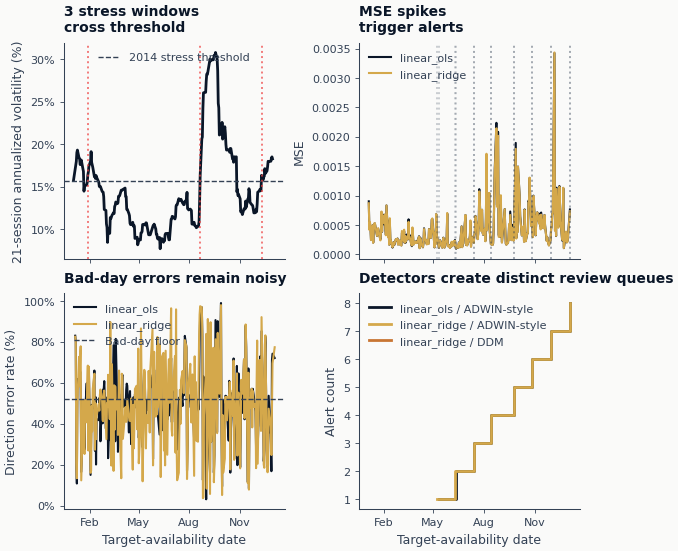

In [20]:
alert_frame = pd.DataFrame(alert_history)
if not alert_frame.empty:
    alert_frame["timestamp"] = pd.to_datetime(alert_frame["timestamp"])

fig, axes = plt.subplots(
    2, 2, figsize=FIGSIZE["dashboard_2x2"], sharex="col", constrained_layout=True
)

ax1 = axes[0, 0]
ax1.plot(prices["timestamp"], prices["rolling_vol_21d"], color=COLORS["blue"], linewidth=2)
ax1.axhline(
    stress_threshold,
    color=COLORS["neutral"],
    linestyle="--",
    linewidth=1,
    label="2014 stress threshold",
)
for stress_date in stress_starts:
    ax1.axvline(stress_date, color=COLORS["negative"], linestyle=":", alpha=0.7)
add_message_title(ax1, f"{len(stress_starts)} stress windows\ncross threshold")
ax1.set_ylabel("21-session annualized volatility (%)")
format_pct_axis(ax1)
ax1.legend()

ax2 = axes[0, 1]
for model_name, color in [("linear_ols", COLORS["blue"]), ("linear_ridge", COLORS["amber"])]:
    model_frame = daily_errors[daily_errors["model"] == model_name]
    ax2.plot(
        model_frame["timestamp"], model_frame["mse"], color=color, linewidth=1.5, label=model_name
    )
if not alert_frame.empty:
    adwin_alerts = alert_frame[alert_frame["detector"] == "ADWIN-style"]
    for _, row in adwin_alerts.iterrows():
        ax2.axvline(row["timestamp"], color=COLORS["neutral"], linestyle=":", alpha=0.25)
add_message_title(ax2, "MSE spikes\ntrigger alerts")
ax2.set_ylabel("MSE")
ax2.legend()

ax3 = axes[1, 0]
for model_name, color in [("linear_ols", COLORS["blue"]), ("linear_ridge", COLORS["amber"])]:
    model_frame = daily_errors[daily_errors["model"] == model_name]
    ax3.plot(
        model_frame["timestamp"],
        model_frame["direction_error_rate"],
        color=color,
        linewidth=1.5,
        label=model_name,
    )
ax3.axhline(0.52, color=COLORS["neutral"], linestyle="--", linewidth=1, label="Bad-day floor")
add_message_title(ax3, "Bad-day errors remain noisy")
ax3.set_ylabel("Direction error rate (%)")
ax3.set_xlabel("Target-availability date")
format_pct_axis(ax3)
ax3.legend()

ax4 = axes[1, 1]
if not alert_frame.empty:
    cumulative = (
        alert_frame.groupby(["timestamp", "model", "detector"]).size().rename("count").reset_index()
    )
    cumulative["series"] = cumulative["model"] + " / " + cumulative["detector"]
    series_colors = [COLORS["blue"], COLORS["amber"], COLORS["copper"], COLORS["slate"]]
    for color, (series_name, series_frame) in zip(series_colors, cumulative.groupby("series")):
        series_frame = series_frame.sort_values("timestamp")
        ax4.step(
            series_frame["timestamp"],
            series_frame["count"].cumsum(),
            where="post",
            linewidth=2,
            label=series_name,
            color=color,
        )
add_message_title(ax4, "Detectors create distinct review queues")
ax4.set_ylabel("Alert count")
ax4.set_xlabel("Target-availability date")
ax4.legend(fontsize=8)

for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

fig.show()

### Detector summary

In [21]:
detector_table

,model,detector,alert_count,first_alert,median_lag_days
0,linear_ols,ADWIN-style,8,2015-05-12,23.5
1,linear_ols,DDM,0,None,NaN
2,linear_ridge,ADWIN-style,8,2015-05-08,8.5
3,linear_ridge,DDM,1,2015-07-23,29.0


**Trading implication**: On a real validation stream the detector is not a
retraining oracle. It is an escalation tool. The useful output is a dated
review queue: which model signaled, which detector signaled, and whether the
cluster coincided with a broader stress regime.

## Key Takeaways

1. ADWIN-style detectors react to sustained mean shifts in the error stream; DDM reacts when the frequency of bad prediction days clusters.
2. A market-stress proxy contextualizes detector alerts; without an independent degradation label, it cannot identify model decay.
3. The operational output is a dated review queue — which model, which detector, and whether the cluster coincided with broader stress.

**Next**: See `03_safe_model_rollout` for incumbent-candidate testing and staged rollout using the same real prediction artifacts.